In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
import pathlib

In [2]:
model_dir = pathlib.Path.cwd().parent
MODEL_PATH = model_dir / "models"
data_dir = model_dir / "datasets"
df = pd.read_csv(data_dir / "synthetic_donor_candidates_clustered.csv")

In [3]:
df.head()
#df.shape


,donor_id,city_id,lat,lon,availability,blood_group,recency_days,frequency_365,days_until_eligible,cluster_id
0,D0000003,C000,30.484728,1.616656,Yes,A+,111,0,0,0
1,D0000006,C000,30.404470,1.472335,Yes,A+,106,4,0,-1
2,D0000016,C000,30.403611,1.511907,Yes,O-,67,2,0,-1
3,D0000018,C000,30.410250,1.501462,Yes,A+,100,1,0,-1
4,D0000019,C000,30.551144,1.724607,Yes,B+,117,2,0,-1


In [4]:
df = df.drop(columns=["days_until_eligible", "availability","recency_days","frequency_365"])

In [6]:
df.head()

,donor_id,city_id,lat,lon,blood_group,cluster_id
0,D0000003,C000,30.484728,1.616656,A+,0
1,D0000006,C000,30.404470,1.472335,A+,-1
2,D0000016,C000,30.403611,1.511907,O-,-1
3,D0000018,C000,30.410250,1.501462,A+,-1
4,D0000019,C000,30.551144,1.724607,B+,-1


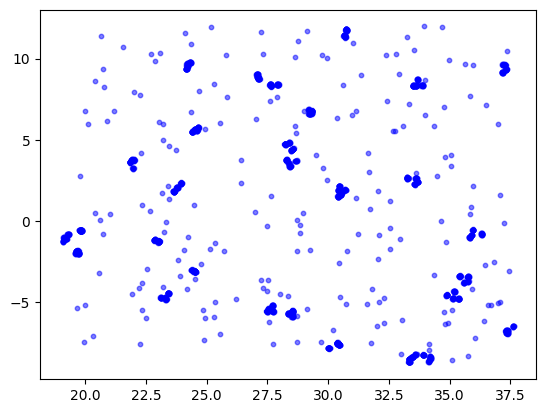

In [7]:
plt.scatter(df["lat"], df["lon"], s=10, alpha=0.5,c="blue")

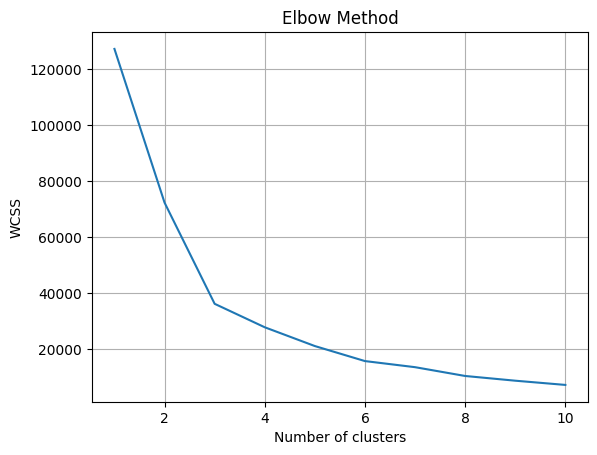

In [8]:
from sklearn.cluster import KMeans
wcss = []
X = df[["lat", "lon"]].dropna().to_numpy()
for k in range(1, 11):
    km = KMeans(n_clusters=k,init='k-means++', max_iter=300, n_init=10)
    km.fit(X)
    wcss.append(km.inertia_)
plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of clusters")    
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

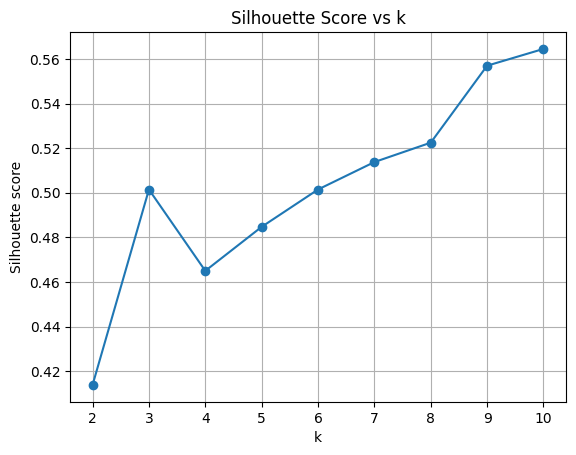

Best k by silhouette: 10 score: 0.5645061173123271


In [9]:
from sklearn.metrics import silhouette_score

df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
df["lon"] = pd.to_numeric(df["lon"], errors="coerce")
X = df[["lat", "lon"]].dropna().to_numpy()

scores = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels) 
    scores.append(score)

plt.plot(list(K), scores, marker="o")
plt.title("Silhouette Score vs k")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()

best_k = list(K)[int(np.argmax(scores))]
print("Best k by silhouette:", best_k, "score:", max(scores))


In [10]:
dbscan = DBSCAN(eps=10, min_samples=10)
labels = dbscan.fit_predict(X)
np.unique(labels)

array([0], dtype=int64)

In [11]:
X_deg = X
X_rad = np.radians(X_deg)

eps_km = 10
eps = eps_km / 6371.0  # Earth radius in km -> radians

dbscan = DBSCAN(eps=eps, min_samples=10, metric="haversine")
labels = dbscan.fit_predict(X_rad)

print(np.unique(labels, return_counts=True))

(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32,
       33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49,
       50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66,
       67, 68, 69, 70, 71, 72, 73], dtype=int64), array([229,  55,  18,  22,  10,  20,  20,  11,  18,  19,  14,  23,  30,
        16,  16,  15,  18,  18,  15,  13,  31,  24,  17,  12,  17,  48,
        11,  20,  18,  17,  11,  58,  33,  27,  23,  19,  19,  44,  14,
        23,  30,  14,  60,  10,  52,  31,  19,  22,  12,  17,  12,  17,
        17,  23,  37,  17,  18,  33,  50,  20,  56,  69,  39,  12,  16,
        37,  21,  17,  31,  12,  26,  29,  20,  22,  10], dtype=int64))


In [12]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = (labels == -1).sum()
print("clusters:", n_clusters, "noise:", n_noise)


clusters: 74 noise: 229


In [13]:
for eps_km in [0.5, 1, 2, 5, 10]:
    eps = eps_km / 6371.0
    labels = DBSCAN(eps=eps, min_samples=10, metric="haversine").fit_predict(X_rad)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    print(eps_km, "km -> clusters:", n_clusters, "noise:", n_noise)


0.5 km -> clusters: 0 noise: 2014
1 km -> clusters: 0 noise: 2014
2 km -> clusters: 26 noise: 1687
5 km -> clusters: 90 noise: 271
10 km -> clusters: 74 noise: 229


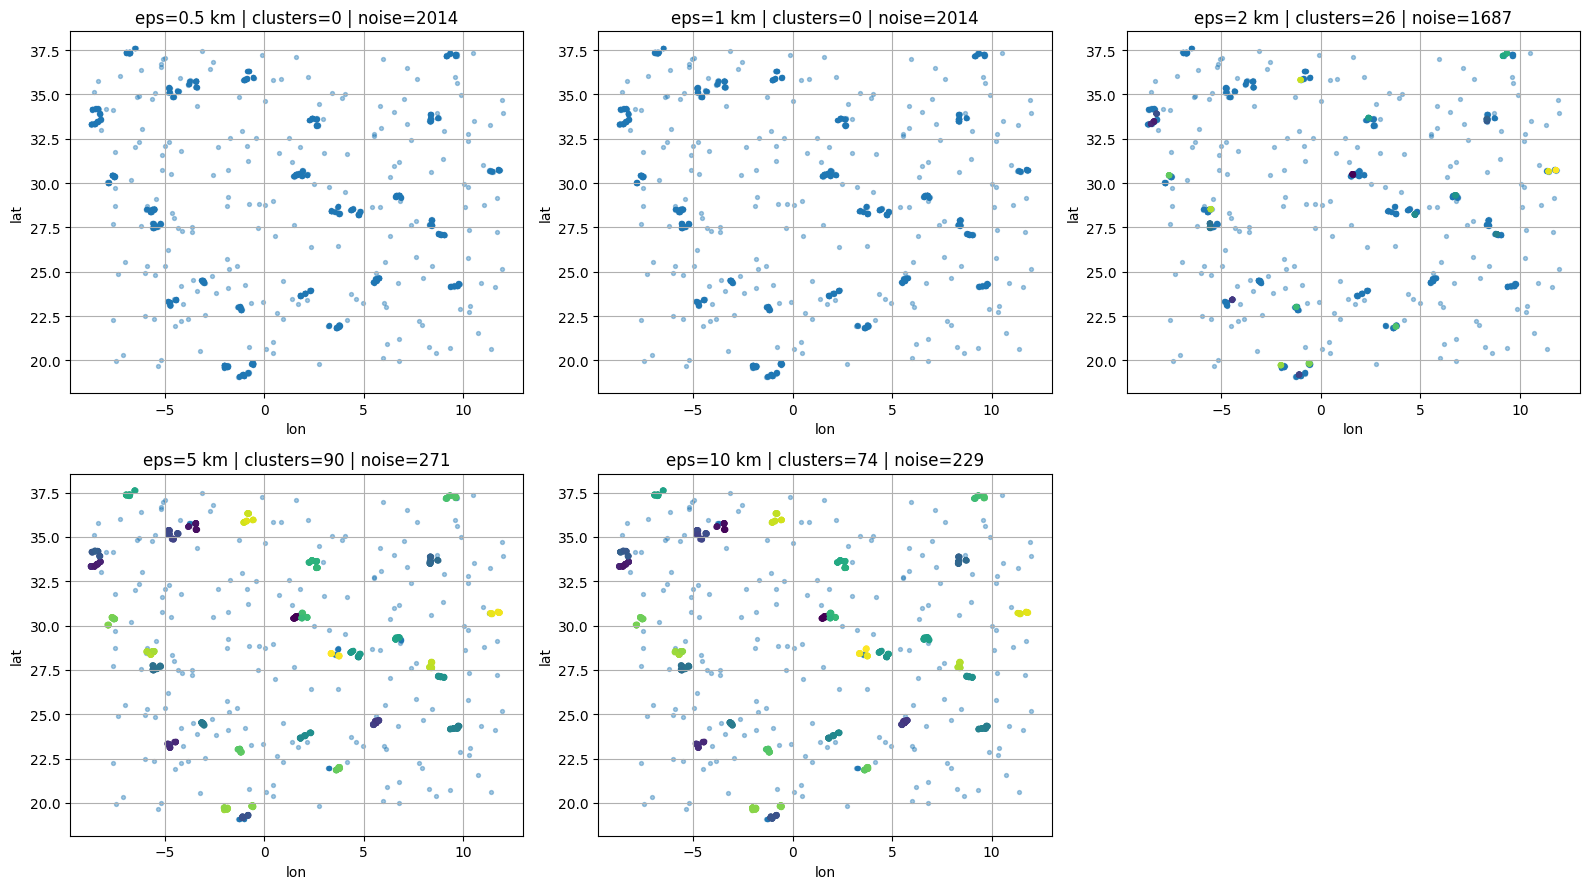

In [14]:
X_deg = X
X_rad = np.radians(X_deg)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# X_deg: (n,2) in degrees -> columns: lat, lon
# X_rad: radians version (n,2)
# Make sure you already have these:
# X_deg = X (lat,lon in degrees)
# X_rad = np.radians(X_deg)

eps_list_km = [0.5, 1, 2, 5, 10]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for i, eps_km in enumerate(eps_list_km):
    eps = eps_km / 6371.0  # km -> radians

    labels = DBSCAN(eps=eps, min_samples=10, metric="haversine").fit_predict(X_rad)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    ax = axes[i]

    # Plot noise separately (label = -1)
    mask_noise = labels == -1
    if mask_noise.any():
        ax.scatter(
            X_deg[mask_noise, 1], X_deg[mask_noise, 0],
            s=8, alpha=0.4, label="noise (-1)"
        )

    # Plot clusters (0,1,2,...)
    mask_cluster = labels != -1
    if mask_cluster.any():
        sc = ax.scatter(
            X_deg[mask_cluster, 1], X_deg[mask_cluster, 0],
            c=labels[mask_cluster], s=10, alpha=0.8
        )

    ax.set_title(f"eps={eps_km} km | clusters={n_clusters} | noise={n_noise}")
    ax.set_xlabel("lon")
    ax.set_ylabel("lat")
    ax.grid(True)

# Hide the last unused subplot (since we have 6 slots but only 5 eps)
axes[-1].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
""" from UniversalModelExporter import UniversalModelExporter

print(dbscan.labels_)
 model_dir = pathlib.Path.cwd().parent
MODEL_PATH = model_dir / "models"

UniversalModelExporter.export_dbscan(
    model=dbscan,
    output_path=MODEL_PATH / "dbscan_model.pkl",
    description="how many days un",
    feature_names=
) """

[ 0  0  0 ... -1 -1 -1]


' model_dir = pathlib.Path.cwd().parent\nMODEL_PATH = model_dir / "models"\n\nUniversalModelExporter.export_xgboost(\n    model=dbscan,\n    output_path=MODEL_PATH / "dbscan_model.pkl",\n    description="how many days un",\n    feature_names=\n) '

Generating 20,000 donors...
Candidates to cluster: 10731
Clustering with eps=3.0km...
Found 42 clusters.


C:\Users\youce\AppData\Local\Temp\ipykernel_33724\2958468903.py:138: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('nipy_spectral')


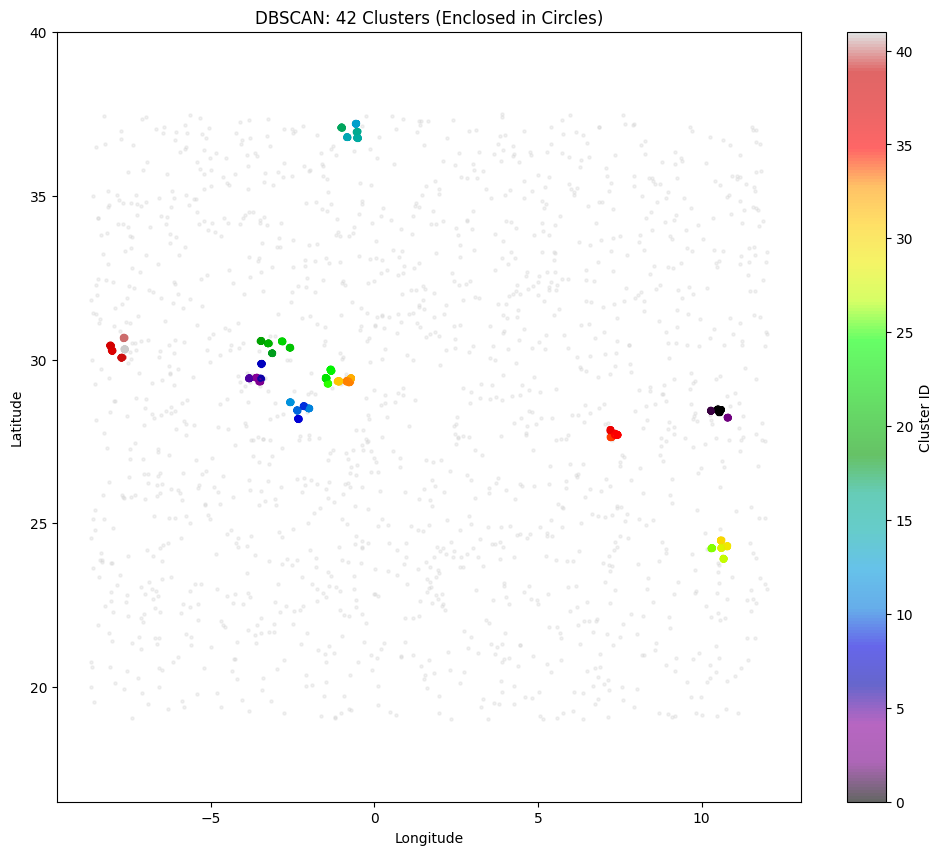

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches # Import patches for drawing circles
from sklearn.cluster import DBSCAN

# -----------------------------
# 1) Synthetic dataset generator (More Data)
# -----------------------------
def generate_synthetic_donors(
    n_donors=20000,      # Increased from 6000
    n_cities=50,         # Increased from 30
    seed=42,
    country_bbox=(19.0, 37.5, -8.7, 12.0),
    city_spread_km=35,
    neighborhood_k=5,    # More neighborhoods per city
    noise_ratio=0.08
):
    rng = np.random.default_rng(seed)
    lat_min, lat_max, lon_min, lon_max = country_bbox

    # Random city centers
    city_centers = np.column_stack([
        rng.uniform(lat_min, lat_max, size=n_cities),
        rng.uniform(lon_min, lon_max, size=n_cities),
    ])

    rows = []
    donor_id = 1

    def km_to_deg_lat(km): 
        return km / 111.0

    donors_per_city = int((1 - noise_ratio) * n_donors / n_cities)
    
    for cidx, (clat, clon) in enumerate(city_centers):
        # Create neighborhood centers
        nb_centers = []
        for _ in range(neighborhood_k):
            dlat = rng.normal(0, km_to_deg_lat(city_spread_km/2))
            dlon = rng.normal(0, km_to_deg_lat(city_spread_km/2) / max(np.cos(np.deg2rad(clat)), 0.2))
            nb_centers.append((clat + dlat, clon + dlon))

        # Generate donors around neighborhoods
        for _ in range(donors_per_city):
            nblat, nblon = nb_centers[rng.integers(0, neighborhood_k)]
            
            # Tighter clusters to make them look distinct
            dlat = rng.normal(0, km_to_deg_lat(1.5)) 
            dlon = rng.normal(0, km_to_deg_lat(1.5) / max(np.cos(np.deg2rad(nblat)), 0.2))
            
            lat = nblat + dlat
            lon = nblon + dlon

            # Simple logic for candidates
            availability = rng.choice(["Yes", "No"], p=[0.70, 0.30])
            days_until_eligible = 0 if rng.random() > 0.3 else 30 # 70% eligible

            rows.append({
                "donor_id": f"D{donor_id:07d}",
                "lat": lat,
                "lon": lon,
                "availability": availability,
                "days_until_eligible": days_until_eligible,
            })
            donor_id += 1

    # Noise donors
    n_noise = n_donors - len(rows)
    for _ in range(n_noise):
        lat = rng.uniform(lat_min, lat_max)
        lon = rng.uniform(lon_min, lon_max)
        
        rows.append({
            "donor_id": f"D{donor_id:07d}",
            "lat": lat,
            "lon": lon,
            "availability": "Yes",
            "days_until_eligible": 0,
        })
        donor_id += 1

    return pd.DataFrame(rows)

# -----------------------------
# 2) Geo DBSCAN
# -----------------------------
def cluster_dbscan_haversine(df, eps_km=50.0, min_samples=30):
    coords_deg = df[["lat", "lon"]].to_numpy()
    coords_rad = np.radians(coords_deg)
    earth_radius_km = 6371.0088
    eps_rad = eps_km / earth_radius_km

    model = DBSCAN(eps=eps_rad, min_samples=min_samples, metric="haversine")
    return model.fit_predict(coords_rad)

# -----------------------------
# 3) Run & Plot with Circles
# -----------------------------
if __name__ == "__main__":
    print("Generating 20,000 donors...")
    df = generate_synthetic_donors(n_donors=20000, n_cities=10, seed=99)

    # Filter for eligible candidates
    candidates = df[(df["days_until_eligible"] == 0) & (df["availability"] == "Yes")].copy()
    print(f"Candidates to cluster: {len(candidates)}")

    # Clustering
    eps_val = 3.0 # 3km radius
    print(f"Clustering with eps={eps_val}km...")
    candidates["cluster_id"] = cluster_dbscan_haversine(candidates, eps_km=eps_val, min_samples=15)

    n_clusters = len(set(candidates["cluster_id"])) - (1 if -1 in candidates["cluster_id"].values else 0)
    print(f"Found {n_clusters} clusters.")

    # --- PLOTTING ---
    fig, ax = plt.subplots(figsize=(12, 10))

    # 1. Plot Noise (small gray dots)
    noise = candidates[candidates["cluster_id"] == -1]
    ax.scatter(noise["lon"], noise["lat"], c='lightgray', s=5, alpha=0.3, label='Noise')

    # 2. Plot Clustered Points
    clustered = candidates[candidates["cluster_id"] != -1]
    
    # We use a colormap to color the points inside
    scatter = ax.scatter(
        clustered["lon"], 
        clustered["lat"], 
        c=clustered["cluster_id"], 
        cmap='nipy_spectral', # 'nipy_spectral' has high contrast for many clusters
        s=10, 
        alpha=0.6
    )

    # 3. Draw Circles around each cluster
    # Get distinct colors from the colormap used above
    cmap = plt.cm.get_cmap('nipy_spectral')
    unique_ids = set(clustered["cluster_id"])
    
    # Normalize IDs for color mapping (0 to 1)
    norm = plt.Normalize(vmin=clustered["cluster_id"].min(), vmax=clustered["cluster_id"].max())

    for cid in unique_ids:
        # Get data for this specific cluster
        points = candidates[candidates["cluster_id"] == cid]
        
        # Calculate Centroid
        center_lon = points["lon"].mean()
        center_lat = points["lat"].mean()
        
        # Calculate Radius (distance from center to furthest point)
        # Approximate Euclidean distance in degrees is fine for visualization
        # Otherwise, calculate Haversine max distance
        dists = np.sqrt((points["lon"] - center_lon)**2 + (points["lat"] - center_lat)**2)
        radius = dists.max() 
        
        # Add a tiny buffer to the radius so points don't sit exactly on the line
        radius_buffer = radius * 1.1

        # Pick color matching the points
        color = cmap(norm(cid))

        # Create the circle patch
        circle = mpatches.Circle(
            (center_lon, center_lat), 
            radius_buffer, 
            facecolor='none',      # Transparent fill
            edgecolor=color,       # Color matching the cluster
            linewidth=1.5,
            linestyle='-',
            alpha=0.9
        )
        ax.add_patch(circle)

        # Optional: Add semi-transparent fill
        circle_fill = mpatches.Circle(
            (center_lon, center_lat), 
            radius_buffer, 
            facecolor=color, 
            edgecolor='none', 
            alpha=0.1
        )
        ax.add_patch(circle_fill)

    plt.colorbar(scatter, label="Cluster ID")
    plt.title(f"DBSCAN: {n_clusters} Clusters (Enclosed in Circles)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    
    # Crucial: Equal aspect ratio ensures circles look like circles, not ovals
    ax.axis('equal') 
    
    plt.show()